## Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling (20 pts)

**Resources:**
- LDA:
    - https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06 
    - https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
    - https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/ 
- BERTopic:
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly 
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html 


In [1]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.9 MB/s eta 0:00:0000:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
from spacy import displacy
import spacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.gensim_models

/home/jovyan/.local/share/envs/sotu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### LDA

- Train an LDA model with 18 topics
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization

You may use the next two cells to process the data.

In [3]:
import pandas as pd
sou = pd.read_csv("data/SOTU.csv") 

nlp = spacy.load("en_core_web_sm")
sou.head()

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169


In [4]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [5]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

To train an LDA model, use the LdaModel function that we imported a couple of cells back. The last resource linked under the LDA section is especially useful for walking through the steps we have below. *Note: one of the arguments to the LdaModel function is `random_state` which specifies the random seed for reproducibility. Please set yours to 42. Further, the last resource provided uses `LdaMulticore` which is essentially a parallelizable version of our function `LdaModel`. Use `LdaModel` instead, but the usage will be similar, except you can ignore the `iterations` and `workers` arguments..*.

In [6]:
from gensim.corpora import Dictionary

dictionary = Dictionary(processed_docs)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [7]:
from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=18,
    random_state=42,
    passes=10
)

In [8]:
for i in range(18):
    print(f"--- Topic {i} ---")
    print(lda_model.print_topic(i, topn=10))
    print()

--- Topic 0 ---
0.013*"states" + 0.013*"government" + 0.009*"united" + 0.008*"congress" + 0.007*"country" + 0.006*"year" + 0.006*"public" + 0.006*"great" + 0.005*"state" + 0.005*"power"

--- Topic 1 ---
0.002*"year" + 0.002*"people" + 0.002*"government" + 0.001*"states" + 0.001*"congress" + 0.001*"country" + 0.001*"nation" + 0.001*"great" + 0.001*"time" + 0.001*"united"

--- Topic 2 ---
0.003*"year" + 0.003*"government" + 0.002*"states" + 0.002*"congress" + 0.002*"united" + 0.002*"people" + 0.002*"great" + 0.002*"service" + 0.002*"public" + 0.001*"increase"

--- Topic 3 ---
0.015*"year" + 0.011*"world" + 0.011*"people" + 0.011*"america" + 0.010*"nation" + 0.007*"help" + 0.007*"congress" + 0.007*"american" + 0.007*"work" + 0.006*"time"

--- Topic 4 ---
0.009*"isthmus" + 0.006*"colombia" + 0.005*"government" + 0.004*"states" + 0.004*"panama" + 0.004*"united" + 0.004*"colombian" + 0.004*"treaty" + 0.003*"year" + 0.003*"congress"

--- Topic 5 ---
0.003*"year" + 0.002*"government" + 0.002*"

In [9]:
lda_model.get_document_topics(corpus[0])


[(7, np.float32(0.9997309))]

In [10]:
# make a visualization using pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.162521 -0.126311       1        1  35.438083
6      0.157323 -0.060432       2        1  25.787725
10     0.178967  0.028782       3        1  13.735866
3      0.202841  0.134162       4        1  12.638032
7      0.168056  0.166615       5        1   7.052381
8      0.155744 -0.155774       6        1   5.078049
16     0.000794  0.007825       7        1   0.169912
17    -0.053576  0.027428       8        1   0.029613
9     -0.058696 -0.027552       9        1   0.027767
4     -0.041461 -0.041372      10        1   0.024963
12    -0.061192 -0.032978      11        1   0.005718
1     -0.128475  0.030088      12        1   0.001699
2     -0.057389  0.009090      13        1   0.001699
5     -0.115087  0.007610      14        1   0.001699
13    -0.091102  0.005346      15        1   0.001699
11    -0.125912 -0.003683      16        1   0.001699
15    -0.136505  0.010673      17        1   0.001699
14    -0.156851  0.020482      18        1   0.001699, topic_info=            Term         Freq        Total Category  logprob  loglift
1525  government  8290.000000  8290.000000  Default  30.0000  30.0000
1066      states  6520.000000  6520.000000  Default  29.0000  29.0000
1250        year  7007.000000  7007.000000  Default  28.0000  28.0000
223     congress  5396.000000  5396.000000  Default  27.0000  27.0000
1185      united  5054.000000  5054.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
141     business     0.005015  1490.473949  Topic18  -7.9191  -1.6192
1009     service     0.005552  2173.415605  Topic18  -7.8174  -1.8947
1417  department     0.005227  1752.772929  Topic18  -7.8778  -1.7400
801        peace     0.005108  1994.063468  Topic18  -7.9008  -1.8920
5000     subject     0.005067  1983.383843  Topic18  -7.9089  -1.8947

[1383 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
9256      4  0.982066  --to
9084      4  0.984218  --we
9111      1  0.814738  1791
9111      4  0.101842  1791
9111      6  0.101842  1791
...     ...       ...   ...
1250      5  0.100321  year
1250      6  0.027114  year
1250      7  0.000571  year
1250      8  0.000143  year
1250     10  0.000143  year

[2020 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 7, 11, 4, 8, 9, 17, 18, 10, 5, 13, 2, 3, 6, 14, 12, 16, 15])

### BERTopic

- Train a BERTopic model with a `min_topic_size` of 3 *Hint: use `BERTopic` to instantiate the model and specify `min_topic_size` in here. Actually fit the model using `fit_transform`, which `docs` passed into this.*
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization of the topics (see topic_model.visualize_topics())

In [11]:
docs = sou['Text'].to_list()


In [12]:
from bertopic import BERTopic

topic_model = BERTopic(min_topic_size=3, verbose=True)
topics, probs = topic_model.fit_transform(docs)

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(stop_words="english")
topic_model.update_topics(docs, vectorizer_model=vectorizer_model)


2025-11-21 22:16:56,922 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:07<00:00,  1.03it/s]
2025-11-21 22:17:06,062 - BERTopic - Embedding - Completed ✓
2025-11-21 22:17:06,063 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 22:17:15,940 - BERTopic - Dimensionality - Completed ✓
2025-11-21 22:17:15,941 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 22:17:15,952 - BERTopic - Cluster - Completed ✓
2025-11-21 22:17:15,955 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 22:17:17,355 - BERTopic - Representation - Completed ✓


In [13]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,56,-1_states_government_united_congress,"[states, government, united, congress, year, n...",[\nJump toPart II |Part III\nPart 1. [On Our F...
1,0,24,0_world_new_people_years,"[world, new, people, years, america, american,...","[\nMr. President, Mr. Speaker, Members of the ..."
2,1,16,1_states_government_united_public,"[states, government, united, public, congress,...",[\nFellow-Citizens of the Senate and House of ...
3,2,12,2_world_nations_soviet_peace,"[world, nations, soviet, peace, economic, free...",[\n[Delivered in person before a joint session...
4,3,12,3_government_united_states_department,"[government, united, states, department, congr...",[\nFellow-Citizens of the Senate and House of ...
5,4,11,4_america_american_americans_people,"[america, american, americans, people, tonight...","[\nThank you all. Madam Speaker, Vice Presiden..."
6,5,11,5_government_work_public_congress,"[government, work, public, congress, great, la...",[\nTo the Senate and House of Representatives:...
7,6,9,6_government_law_states_united,"[government, law, states, united, gold, congre...",[\nTo the Senate and House of Representatives:...
8,7,9,7_america_new_americans_american,"[america, new, americans, american, tonight, j...","[\nThe President. Mr. Speaker, Mr. Vice Presid..."
9,8,8,8_government_states_public_united,"[government, states, public, united, general, ...",[\nFellow-Citizens of the Senate and House of ...


In [14]:
print("Number of Topics:", len(topic_model.get_topics()))
topic_model.get_topic_info().head(20)


Number of Topics: 26


,Topic,Count,Name,Representation,Representative_Docs
0,-1,56,-1_states_government_united_congress,"[states, government, united, congress, year, n...",[\nJump toPart II |Part III\nPart 1. [On Our F...
1,0,24,0_world_new_people_years,"[world, new, people, years, america, american,...","[\nMr. President, Mr. Speaker, Members of the ..."
2,1,16,1_states_government_united_public,"[states, government, united, public, congress,...",[\nFellow-Citizens of the Senate and House of ...
3,2,12,2_world_nations_soviet_peace,"[world, nations, soviet, peace, economic, free...",[\n[Delivered in person before a joint session...
4,3,12,3_government_united_states_department,"[government, united, states, department, congr...",[\nFellow-Citizens of the Senate and House of ...
5,4,11,4_america_american_americans_people,"[america, american, americans, people, tonight...","[\nThank you all. Madam Speaker, Vice Presiden..."
6,5,11,5_government_work_public_congress,"[government, work, public, congress, great, la...",[\nTo the Senate and House of Representatives:...
7,6,9,6_government_law_states_united,"[government, law, states, united, gold, congre...",[\nTo the Senate and House of Representatives:...
8,7,9,7_america_new_americans_american,"[america, new, americans, american, tonight, j...","[\nThe President. Mr. Speaker, Mr. Vice Presid..."
9,8,8,8_government_states_public_united,"[government, states, public, united, general, ...",[\nFellow-Citizens of the Senate and House of ...


In [19]:
from bertopic import BERTopic

topic_model = BERTopic(min_topic_size=3, calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)



2025-11-21 22:21:11,951 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:21<00:00,  2.67s/it]
2025-11-21 22:21:34,674 - BERTopic - Embedding - Completed ✓
2025-11-21 22:21:34,674 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 22:21:40,358 - BERTopic - Dimensionality - Completed ✓
2025-11-21 22:21:40,361 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 22:21:40,382 - BERTopic - Cluster - Completed ✓
2025-11-21 22:21:40,385 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 22:21:41,795 - BERTopic - Representation - Completed ✓


100%|██████████| 1/1 [00:00<00:00, 19.69it/s]


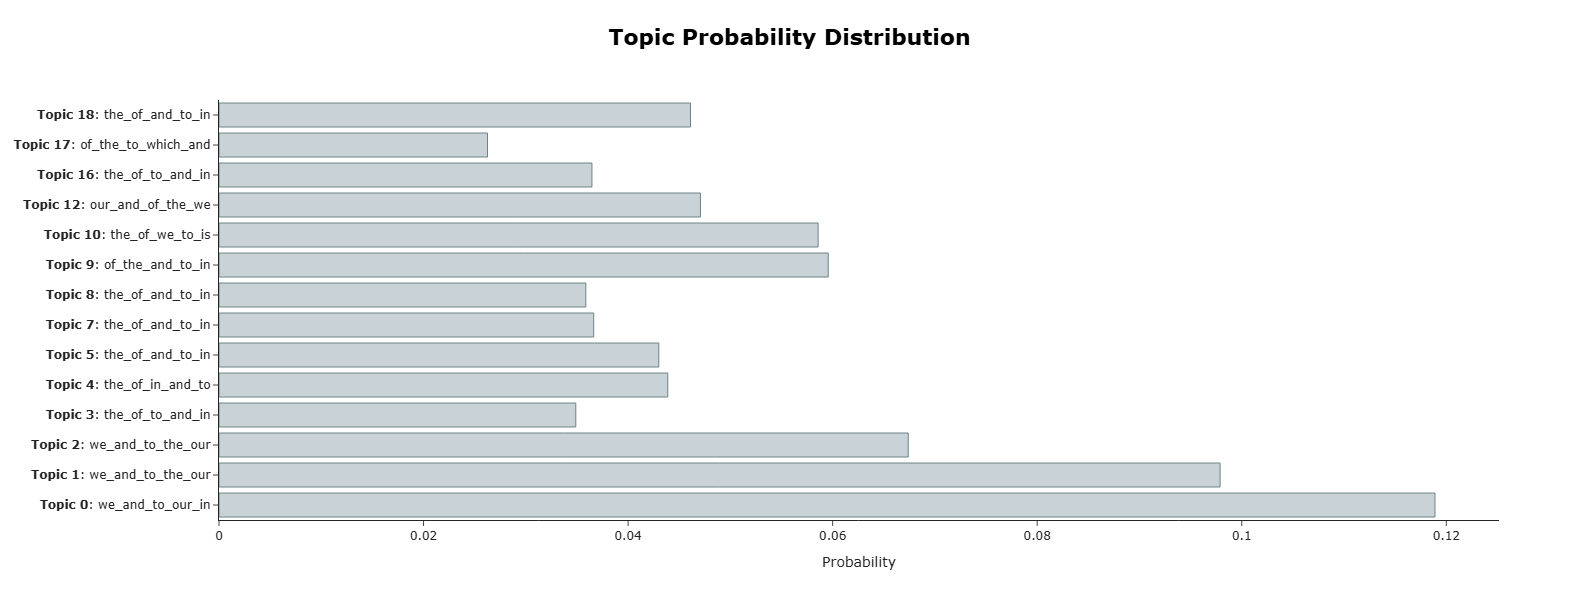

In [38]:
# Get the same distribution you were using before
probs_first = topic_model.approximate_distribution(docs[0:1])[0][0]

import numpy as np
probs_first = np.array(probs_first)

# Topics to exclude (21 is NOT in this list)
exclude = np.array([6, 11, 13, 14, 15, 19, 20])

# Zero out only those topics so they disappear from the plot
probs_first[exclude] = 0

# Plot – x-axis stays the same scale as the original distribution
topic_model.visualize_distribution(probs_first)



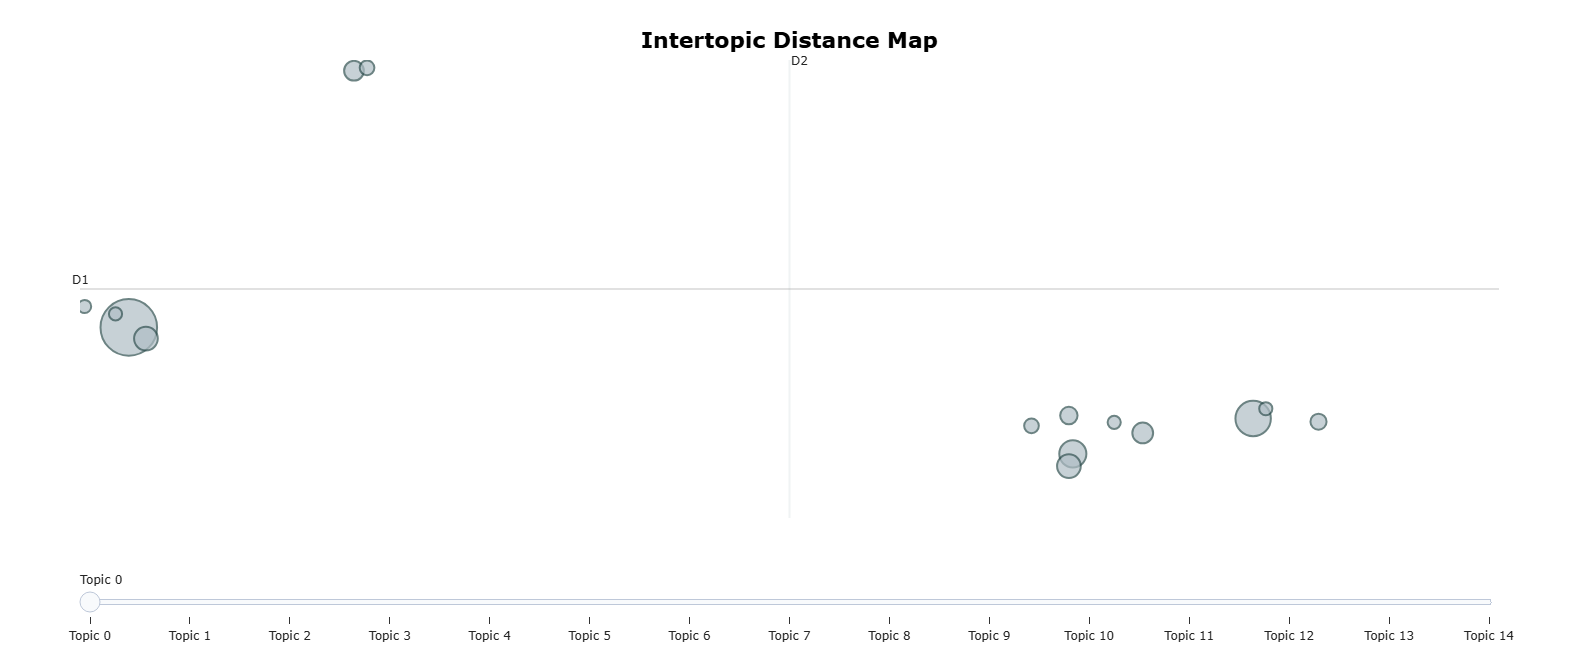

In [18]:
# run this cell to visualize the topics
topic_model.visualize_topics()